In [1]:
#input files. Do not touch.
import pandas as pd
import glob
import re

# Load training.csv
training = pd.read_csv("training.csv")

# Load all evalN.csv files into separate dataframes named evaluationN
eval_files = glob.glob("eval*.csv")
for f in eval_files:
    match = re.search(r'eval(\d+)\.csv', f)
    if match:
        n = match.group(1)
        df_name = f"evaluation{n}"
        globals()[df_name] = pd.read_csv(f)

In [2]:
# ── Build per-ID profile from training data ────────────────────────────────
import numpy as np
import pandas as pd


def _hex_to_bytes(hex_str):
    """Convert a hex payload string to a list of byte integers. Returns None
    if the string has an odd length (malformed) or is empty."""
    s = str(hex_str)
    if len(s) == 0 or len(s) % 2 != 0:
        return None
    return [int(s[i:i + 2], 16) for i in range(0, len(s), 2)]


def build_profile(train_df):
    """
    Learn normal behaviour from training data (attack-free).
    Returns a dict with per-ID statistics used at detection time.
    """
    df = train_df.sort_values("timestamp").copy()

    # Inter-arrival time (IAT) of each arbitration_id
    df["iat"] = df.groupby("arbitration_id")["timestamp"].diff()
    iat_stats = (
        df.groupby("arbitration_id")["iat"]
        .agg(["mean", "std"])
        .rename(columns={"mean": "iat_mean", "std": "iat_std"})
    )
    # Use 6-sigma lower bound; minimum floor of 0.001 s to avoid false positives
    iat_stats["iat_min"] = np.maximum(
        iat_stats["iat_mean"] - 6 * iat_stats["iat_std"], 0.001
    )

    # Set of known arbitration IDs
    known_ids = set(train_df["arbitration_id"].unique())

    # Per-ID data-field set (kept for potential future use / inspection)
    known_data = (
        train_df.groupby("arbitration_id")["data_field"]
        .apply(set)
        .to_dict()
    )

    # Per-ID data-field length (byte count = hex chars / 2)
    df["data_len"] = train_df["data_field"].str.len()
    data_len_stats = (
        df.groupby("arbitration_id")["data_len"]
        .agg(["mean", "std", "min", "max"])
    )

    # ── Per-ID, per-byte "plausible step size" model ────────────────────────
    # Real CAN signals can only change by a bounded amount from one frame to
    # the next of the *same* ID (physical quantities are continuous). We
    # learn, per ID and per byte position, the largest single-step change
    # ever observed in training, plus a robust mean+6*std estimate (to avoid
    # under-estimating the bound from finite training samples). The detector
    # later flags a frame whose payload jumps further than this learned
    # bound from the last *trusted* frame of that ID - this is what catches
    # "masquerade" attacks that reuse a known ID and a known timing slot but
    # inject a forged payload.
    modal_len = {}
    delta_thresh = {}
    for arb_id, g in df.groupby("arbitration_id"):
        g = g.sort_values("timestamp")
        lens = g["data_field"].str.len()
        if len(lens) == 0:
            continue
        mlen = lens.mode().iloc[0]
        modal_len[arb_id] = mlen

        gg = g[lens == mlen]
        if mlen > 0 and mlen % 2 == 0 and len(gg) >= 2:
            byte_df = gg["data_field"].apply(_hex_to_bytes).apply(pd.Series)
            deltas = byte_df.diff().abs().iloc[1:]
            d_max = deltas.max().values
            d_mean = deltas.mean().values
            d_std = deltas.std(ddof=0).fillna(0).values
            delta_thresh[arb_id] = np.maximum(d_max, d_mean + 6 * d_std)
        else:
            delta_thresh[arb_id] = None

    return {
        "known_ids": known_ids,
        "iat_stats": iat_stats,
        "known_data": known_data,
        "data_len_stats": data_len_stats,
        "modal_len": modal_len,
        "delta_thresh": delta_thresh,
    }


PROFILE = build_profile(training)


# ── Detection logic ────────────────────────────────────────────────────────

# Tunable parameters for the payload-jump rule (rule 4). A multiplicative
# margin and a small additive buffer are applied on top of the
# training-learned per-byte step bound, to absorb natural variability that a
# finite training sample doesn't fully cover, while still catching forged
# payloads injected on a known ID/timing slot.
_DELTA_MARGIN = 1.1
_DELTA_ADDITIVE = 7.0


def ids(eval_df):
    """
    Classify each packet in eval_df as attack (1) or not (0).

    Strategy (CAN-bus aware, threshold-based):
    1. Unknown arbitration ID  → attack
       Normal CAN traffic uses a fixed, known set of IDs.  Any frame whose
       ID was never seen in training is either a fuzzy-attack fabricated ID
       or a DoS/replay injected with a spoofed ID.

    2. IAT too short for this ID  → attack
       Each ID has a nearly fixed period.  Injection and DoS attacks flood
       the bus with extra frames, causing IATs far below the normal minimum.
       We flag any frame whose IAT < iat_min (mean − 6 σ, floored at 1 ms).

    3. Data-field length mismatch  → attack
       Each ID consistently uses the same payload length.  A frame with a
       different length is anomalous (fuzzy attack or malformed injection).

    4. Implausible payload jump (masquerade detector)  → attack
       Some attacks reuse a *known* ID at its *normal* timing (so rules 1-3
       can't see them) but forge the payload. Physical signals can't jump
       further between consecutive frames of the same ID than what training
       ever showed. We track, per ID, the last frame that was judged
       trustworthy (i.e., not already flagged) and flag the current frame if
       any byte moves further than the learned per-byte bound from that
       trusted frame. Because the baseline is only updated on frames that
       pass the check, an attacker who holds an ID at a different forged
       level keeps tripping the rule for as long as the forged level stays
       far from the last genuine value - not just on the first injected
       frame.
    """
    profile = PROFILE
    known_ids = profile["known_ids"]
    iat_stats = profile["iat_stats"]
    data_len_stats = profile["data_len_stats"]
    modal_len = profile["modal_len"]
    delta_thresh = profile["delta_thresh"]

    df = eval_df.sort_values("timestamp").copy()
    df["predicted_attack"] = 0

    # Rule 1: unknown arbitration ID
    unknown_mask = ~df["arbitration_id"].isin(known_ids)
    df.loc[unknown_mask, "predicted_attack"] = 1

    # Rule 2: IAT anomaly (too frequent)
    df["iat"] = df.groupby("arbitration_id")["timestamp"].diff()

    ids_with_iat = iat_stats[iat_stats["iat_min"].notna()].index
    for arb_id in ids_with_iat:
        if arb_id not in known_ids:
            continue  # already flagged
        iat_min = iat_stats.loc[arb_id, "iat_min"]
        mask = (
            (df["arbitration_id"] == arb_id)
            & df["iat"].notna()
            & (df["iat"] < iat_min)
        )
        df.loc[mask, "predicted_attack"] = 1

    # Rule 3: data-field length mismatch
    df["data_len"] = df["data_field"].str.len()
    for arb_id, row in data_len_stats.iterrows():
        if arb_id not in known_ids:
            continue
        expected_min = row["min"]
        expected_max = row["max"]
        mask = (
            (df["arbitration_id"] == arb_id)
            & (
                (df["data_len"] < expected_min)
                | (df["data_len"] > expected_max)
            )
        )
        df.loc[mask, "predicted_attack"] = 1

    # Rule 4: implausible payload jump (masquerade detector)
    rule4_flag = np.zeros(len(df), dtype=int)
    df_reset = df.reset_index()  # preserve original positional index
    for arb_id, g in df_reset.groupby("arbitration_id"):
        if arb_id not in known_ids:
            continue
        thresh = delta_thresh.get(arb_id)
        mlen = modal_len.get(arb_id)
        if thresh is None or mlen is None:
            continue

        g = g.sort_values("timestamp")
        same_len_mask = g["data_field"].str.len() == mlen
        sub = g[same_len_mask]
        if len(sub) < 2:
            continue

        byte_vals = sub["data_field"].apply(_hex_to_bytes).apply(pd.Series).values.astype(float)
        bound = np.array(thresh) * _DELTA_MARGIN + _DELTA_ADDITIVE

        last_trusted = byte_vals[0]
        local_flags = np.zeros(len(sub), dtype=int)
        for i in range(1, len(sub)):
            diff = np.abs(byte_vals[i] - last_trusted)
            if np.any(diff > bound):
                local_flags[i] = 1
                # do not update last_trusted: keep comparing against the
                # last genuinely-trusted frame while the deviation persists
            else:
                last_trusted = byte_vals[i]

        rule4_flag[sub["index"].values] = local_flags

    df["predicted_attack"] = np.maximum(df["predicted_attack"].values, rule4_flag)

    # Restore original row order and drop helper columns
    result_df = df.sort_index().drop(columns=["iat", "data_len"])
    return result_df


evaluation1 Evaluation Metrics:
  Accuracy: 0.9903
  Precision: 0.9761
  Recall: 1.0000
  F1_score: 0.9879

evaluation2 Evaluation Metrics:
  Accuracy: 0.9378
  Precision: 0.6850
  Recall: 1.0000
  F1_score: 0.8130

evaluation3 Evaluation Metrics:
  Accuracy: 0.9748
  Precision: 0.4737
  Recall: 1.0000
  F1_score: 0.6429

evaluation4 Evaluation Metrics:
  Accuracy: 0.9776
  Precision: 0.9313
  Recall: 0.9992
  F1_score: 0.9640

evaluation5 Evaluation Metrics:
  Accuracy: 0.9850
  Precision: 0.6019
  Recall: 1.0000
  F1_score: 0.7515

evaluation6 Evaluation Metrics:
  Accuracy: 0.9649
  Precision: 0.4235
  Recall: 0.9464
  F1_score: 0.5852

Average Evaluation Metrics:
  Accuracy: 0.9717
  Precision: 0.6819
  Recall: 0.9909
  F1_score: 0.7907


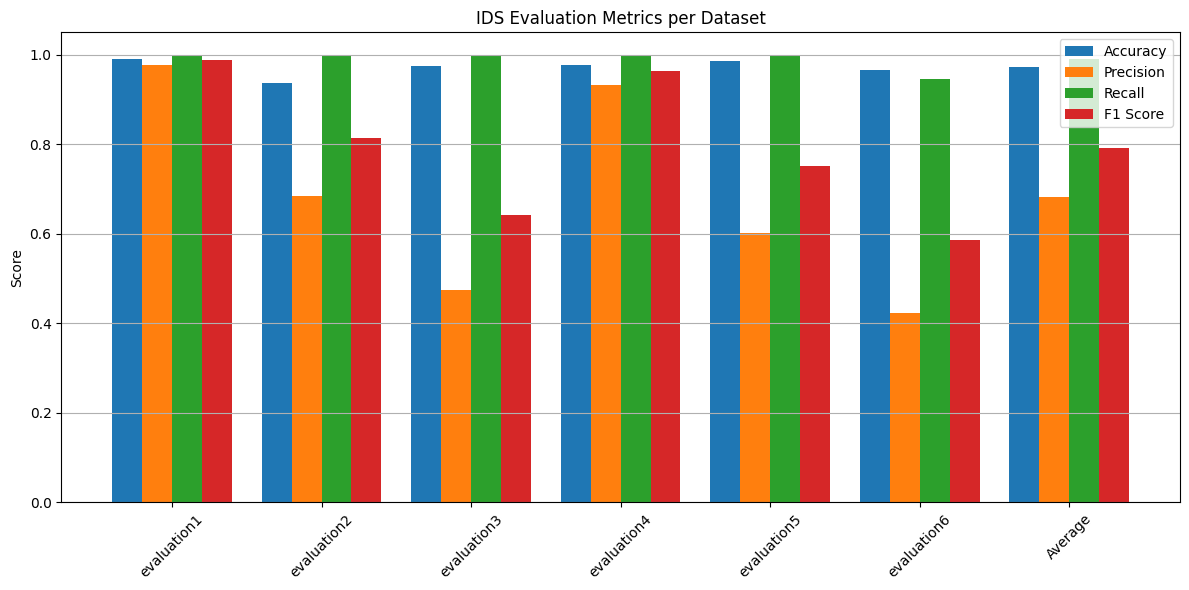


Total Elapsed Time: 7.68 seconds


In [3]:
#evaluation sequence. Do not touch.
import time  # Add this
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

start_time = time.time()  # Start timing

evaluation_metrics = {}
all_globals = list(globals().items())

# Loop through evaluation dataframes
for name, df in all_globals:
    if name.startswith("evaluation") and isinstance(df, pd.DataFrame):
        # Run IDS
        #print("running " + name)
        detected_df = ids(df)
        
        # Compare predictions to ground truth
        y_true = detected_df['attack']
        y_pred = detected_df['predicted_attack']
        
        # Compute metrics
        metrics = {
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1_score': f1_score(y_true, y_pred, zero_division=0),
        }
        
        evaluation_metrics[name] = metrics

# Compute average metrics
avg_metrics = {
    metric: np.mean([metrics[metric] for metrics in evaluation_metrics.values()])
    for metric in ['accuracy', 'precision', 'recall', 'f1_score']
}
evaluation_metrics['Average'] = avg_metrics

# Display metrics
for name, metrics in evaluation_metrics.items():
    print(f"\n{name} Evaluation Metrics:")
    for metric, value in metrics.items():
        print(f"  {metric.capitalize()}: {value:.4f}")

# Plotting
labels = list(evaluation_metrics.keys())
x = np.arange(len(labels))
width = 0.2

# Prepare metric lists
accuracy = [evaluation_metrics[label]['accuracy'] for label in labels]
precision = [evaluation_metrics[label]['precision'] for label in labels]
recall = [evaluation_metrics[label]['recall'] for label in labels]
f1 = [evaluation_metrics[label]['f1_score'] for label in labels]

# Create the bar chart
plt.figure(figsize=(12, 6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall, width, label='Recall')
plt.bar(x + 1.5*width, f1, width, label='F1 Score')

plt.xticks(x, labels, rotation=45)
plt.ylabel('Score')
plt.title('IDS Evaluation Metrics per Dataset')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.grid(axis='y')
plt.show()

# End timing
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTotal Elapsed Time: {elapsed_time:.2f} seconds")